# 03 — Leakage-safe feature engineering and XGBoost comparison

**Business question:** Can we materially reduce false positives while maintaining approximately **80% fraud recall**?

Compares three models under the same chronological split and validation-only operating policy:

| Model | Description |
| --- | --- |
| **A** | Frozen Task 2 Logistic Regression baseline |
| **B** | Logistic Regression + engineered features |
| **C** | XGBoost on the same engineered feature set |

Core logic lives in `fraud_risk.dataset`, `fraud_risk.features`, and `fraud_risk.modeling`.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
SRC = REPO_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from fraud_risk.data import load_raw_data
from fraud_risk.dataset import (
    BASELINE_FEATURES,
    EXCLUDED_BASELINE_COLUMNS,
    TARGET_COLUMN,
    build_modeling_dataset,
    split_target_summary,
)
from fraud_risk.features import (
    ENGINEERED_FEATURE_NAMES,
    ENGINEERED_MODEL_FEATURES,
    ZERO_BALANCE_RATIO_DENOMINATOR,
    add_engineered_features,
    prepare_engineered_model_frame,
)
from fraud_risk.modeling import (
    DEFAULT_RECALL_FLOOR,
    build_logistic_baseline_pipeline,
    build_logistic_engineered_pipeline,
    build_xgboost_pipeline,
    classification_metrics_at_threshold,
    compute_scale_pos_weight,
    predict_proba_positive,
    ranking_metrics,
    relative_false_positive_reduction,
    select_operating_threshold,
)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.6f}" if abs(x) < 1 else f"{x:,.4f}")
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3, "figure.figsize": (7, 4)})

raw = load_raw_data(REPO_ROOT / "data" / "raw")
print(f"Loaded raw PaySim: {len(raw):,} rows")
print(f"Recall floor (operating policy): {DEFAULT_RECALL_FLOOR:.0%}")
print(f"Excluded columns: {EXCLUDED_BASELINE_COLUMNS}")


Loaded raw PaySim: 6,362,620 rows
Recall floor (operating policy): 80%
Excluded columns: ('nameOrig', 'nameDest', 'newbalanceOrig', 'newbalanceDest', 'oldbalanceDest', 'isFlaggedFraud')


## 1. Objective

The Task 2 baseline found useful fraud signal but produced a large alert volume. At the frozen validation-selected policy, test performance was roughly **82% recall / 8.4% precision** with tens of thousands of false positives.

Task 3 keeps the same prediction moment (**immediately before authorization**), the same V1 scope (`TRANSFER` / `CASH_OUT`), and the same chronological split. We ask whether a small engineered feature set and/or a nonlinear XGBoost model can reduce false positives at approximately **80% recall**.

We do **not** optimize for accuracy or ROC-AUC as the primary objective.


In [2]:
split = build_modeling_dataset(raw)
summary = split_target_summary(split.train, split.validation, split.test)
display(summary)

print(
    f"Step ranges — train: {split.boundaries.train_steps[0]}–{split.boundaries.train_max_step}, "
    f"val: {split.boundaries.validation_min_step}–{split.boundaries.validation_max_step}, "
    f"test: {split.boundaries.test_min_step}–{split.boundaries.test_steps[-1]}"
)

y_train = split.train[TARGET_COLUMN]
y_val = split.validation[TARGET_COLUMN]
y_test = split.test[TARGET_COLUMN]

X_train_a = split.train.loc[:, list(BASELINE_FEATURES)]
X_val_a = split.validation.loc[:, list(BASELINE_FEATURES)]
X_test_a = split.test.loc[:, list(BASELINE_FEATURES)]


,split,rows,pct_rows,fraud_cases,fraud_rate,min_step,max_step
0,train,1938484,0.699710,3633,0.001874,1,322
1,validation,415628,0.150024,560,0.001347,323,376
2,test,416297,0.150266,4020,0.009657,377,743


Step ranges — train: 1–322, val: 323–376, test: 377–743


## 2. Existing Baseline (Model A)

Frozen Task 2 configuration:

- Features: `type`, `amount`, `oldbalanceOrg`
- Model: Logistic Regression, `class_weight='balanced'`
- No retrospective changes to this baseline


In [3]:
model_a = build_logistic_baseline_pipeline()
model_a.fit(X_train_a, y_train)
score_a_val = predict_proba_positive(model_a, X_val_a)
score_a_test = predict_proba_positive(model_a, X_test_a)
print("Model A fitted on baseline features:", list(BASELINE_FEATURES))
print(f"Validation score range: [{score_a_val.min():.4f}, {score_a_val.max():.4f}]")


Model A fitted on baseline features: ['type', 'amount', 'oldbalanceOrg']
Validation score range: [0.0000, 1.0000]


## 3. Leakage-Safe Feature Engineering

Derived only from `type`, `amount`, and `oldbalanceOrg`:

| Feature | Definition |
| --- | --- |
| `log_amount` | `log1p(amount)` |
| `log_origin_balance` | `log1p(oldbalanceOrg)` |
| `amount_to_balance_ratio` | `amount / oldbalanceOrg` if balance > 0; else `amount / 1.0` |
| `origin_balance_zero` | 1 if `oldbalanceOrg == 0`, else 0 |
| `amount_exceeds_balance` | 1 if `amount > oldbalanceOrg`, else 0 |

**Zero-balance ratio rule:** when `oldbalanceOrg == 0`, divide by `1.0` (`ZERO_BALANCE_RATIO_DENOMINATOR`) so the ratio stays finite and proportional to amount. No NaNs or infinities.

Still excluded: IDs, post-transaction balances, `oldbalanceDest`, `isFlaggedFraud`.


In [4]:
print(f"ZERO_BALANCE_RATIO_DENOMINATOR = {ZERO_BALANCE_RATIO_DENOMINATOR}")
print(f"Engineered names: {ENGINEERED_FEATURE_NAMES}")
print(f"Model B/C features: {ENGINEERED_MODEL_FEATURES}")

demo = add_engineered_features(split.train.head(8).copy())
display(demo.loc[:, list(BASELINE_FEATURES) + list(ENGINEERED_FEATURE_NAMES)])

# Sanity: engineered columns are finite on the full train split
train_fe = add_engineered_features(split.train)
assert np.isfinite(train_fe.loc[:, list(ENGINEERED_FEATURE_NAMES)].to_numpy(dtype=float)).all()
print("Train engineered features are all finite.")

X_train_bc = prepare_engineered_model_frame(split.train)
X_val_bc = prepare_engineered_model_frame(split.validation)
X_test_bc = prepare_engineered_model_frame(split.test)
assert list(X_train_bc.columns) == list(ENGINEERED_MODEL_FEATURES)
for col in EXCLUDED_BASELINE_COLUMNS:
    assert col not in X_train_bc.columns
print(f"Engineered matrices: train={X_train_bc.shape}, val={X_val_bc.shape}, test={X_test_bc.shape}")


ZERO_BALANCE_RATIO_DENOMINATOR = 1.0
Engineered names: ('log_amount', 'log_origin_balance', 'amount_to_balance_ratio', 'origin_balance_zero', 'amount_exceeds_balance')
Model B/C features: ('type', 'amount', 'oldbalanceOrg', 'log_amount', 'log_origin_balance', 'amount_to_balance_ratio', 'origin_balance_zero', 'amount_exceeds_balance')


,type,amount,oldbalanceOrg,log_amount,log_origin_balance,amount_to_balance_ratio,origin_balance_zero,amount_exceeds_balance
2,TRANSFER,181.0000,181.0000,5.2040,5.2040,1.0000,0,0
3,CASH_OUT,181.0000,181.0000,5.2040,5.2040,1.0000,0,0
15,CASH_OUT,"229,133.9400","15,325.0000",12.3421,9.6373,14.9516,0,1
19,TRANSFER,"215,310.3000",705.0000,12.2798,6.5596,305.4047,0,1
24,TRANSFER,"311,685.8900","10,835.0000",12.6498,9.2906,28.7666,0,1
42,CASH_OUT,"110,414.7100","26,845.4100",11.6120,10.1979,4.1130,0,1
47,CASH_OUT,"56,953.9000","1,942.0200",10.9500,7.5720,29.3271,0,1
48,CASH_OUT,"5,346.8900",0.000000,8.5845,0.000000,"5,346.8900",1,1


Train engineered features are all finite.


Engineered matrices: train=(1938484, 8), val=(415628, 8), test=(416297, 8)


## 4. Engineered Logistic Regression (Model B)

Same class-weighted Logistic Regression pattern as Model A, with one-hot `type` and standardized numerics, now including the engineered columns. No hyperparameter tuning.


In [5]:
model_b = build_logistic_engineered_pipeline()
model_b.fit(X_train_bc, y_train)
score_b_val = predict_proba_positive(model_b, X_val_bc)
score_b_test = predict_proba_positive(model_b, X_test_bc)
print("Model B fitted.")
print(f"Validation score range: [{score_b_val.min():.4f}, {score_b_val.max():.4f}]")


Model B fitted.
Validation score range: [0.0000, 1.0000]


## 5. XGBoost (Model C)

Same feature information as Model B. Class imbalance is handled with `scale_pos_weight = n_neg / n_pos` computed from the **training labels only**.

Configuration is intentionally small and fixed (no GridSearch / Optuna). Scores are raw model outputs for ranking and thresholding — **not calibrated probabilities**.


In [6]:
scale_pos_weight = compute_scale_pos_weight(y_train)
print(f"Train positives: {int((y_train == 1).sum()):,}")
print(f"Train negatives: {int((y_train == 0).sum()):,}")
print(f"scale_pos_weight (train only): {scale_pos_weight:.4f}")

model_c = build_xgboost_pipeline(scale_pos_weight=scale_pos_weight)
model_c.fit(X_train_bc, y_train)
score_c_val = predict_proba_positive(model_c, X_val_bc)
score_c_test = predict_proba_positive(model_c, X_test_bc)
print("Model C fitted.")
print(f"Validation score range: [{score_c_val.min():.4f}, {score_c_val.max():.4f}]")
print("Note: XGBoost scores are not calibrated probabilities.")


Train positives: 3,633
Train negatives: 1,934,851
scale_pos_weight (train only): 532.5767


Model C fitted.
Validation score range: [0.0001, 1.0000]
Note: XGBoost scores are not calibrated probabilities.


## 6. Validation Ranking Performance

Threshold-independent metrics on the validation split only.


In [7]:
models = {
    "A_baseline_logreg": (score_a_val, score_a_test),
    "B_engineered_logreg": (score_b_val, score_b_test),
    "C_xgboost": (score_c_val, score_c_test),
}

ranking_rows = []
for name, (s_val, _) in models.items():
    m = ranking_metrics(y_val, s_val)
    ranking_rows.append({"model": name, **m})
ranking_val = pd.DataFrame(ranking_rows)
display(ranking_val)


,model,fraud_prevalence,average_precision,roc_auc
0,A_baseline_logreg,0.001347,0.146530,0.961583
1,B_engineered_logreg,0.001347,0.481893,0.998728
2,C_xgboost,0.001347,1.0000,1.000000


## 7. Operating Threshold Comparison

**Policy (validation only):** among candidate thresholds from a fine 0.01 grid plus precision-recall curve cutoffs, select the threshold with **highest precision** subject to **recall ≥ 80%**. If infeasible, fall back to maximum F1.

The same rule is applied independently to each model. Thresholds are **not** chosen using the test set.

Primary operational comparison: **false positives at approximately 80% recall**.



A_baseline_logreg: threshold=0.592000
  Highest-precision threshold among those with recall >= 80% (provisional portfolio-project policy; validation data only).
  precision=0.0165, recall=0.8000, FP=26,702, alerts=27,150



B_engineered_logreg: threshold=0.919000
  Highest-precision threshold among those with recall >= 80% (provisional portfolio-project policy; validation data only).
  precision=0.3155, recall=0.8018, FP=974, alerts=1,423



C_xgboost: threshold=0.999000
  Highest-precision threshold among those with recall >= 80% (provisional portfolio-project policy; validation data only).
  precision=1.0000, recall=1.0000, FP=0, alerts=560


,model,PR-AUC,ROC-AUC,Threshold,Precision,Recall,F1,False Positives,True Positives,Alerts,Alert Rate,FP reduction vs A
0,A_baseline_logreg,0.146530,0.961583,0.592000,0.016501,0.800000,0.032335,26702,448,27150,0.065323,0.000000
1,B_engineered_logreg,0.481893,0.998728,0.919000,0.315531,0.801786,0.452849,974,449,1423,0.003424,0.963523
2,C_xgboost,1.0000,1.000000,0.999000,1.0000,1.0000,1.0000,0,560,560,0.001347,1.0000


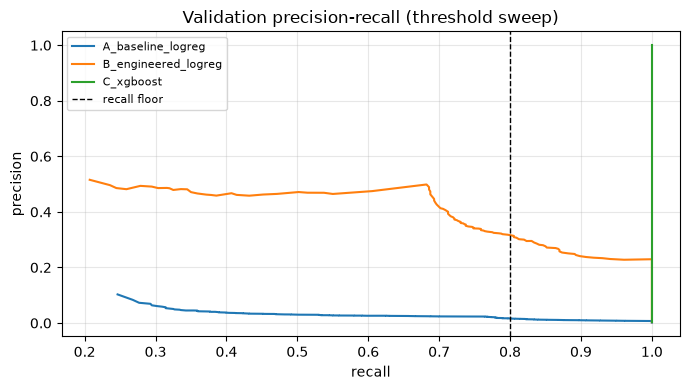

In [8]:
operating = {}
op_rows = []
for name, (s_val, _) in models.items():
    thr, reason, table = select_operating_threshold(y_val, s_val, recall_floor=DEFAULT_RECALL_FLOOR)
    metrics = classification_metrics_at_threshold(y_val, s_val, threshold=thr)
    operating[name] = {"threshold": thr, "reason": reason, "table": table, "metrics": metrics}
    op_rows.append(
        {
            "model": name,
            "PR-AUC": metrics["average_precision"],
            "ROC-AUC": metrics["roc_auc"],
            "Threshold": thr,
            "Precision": metrics["precision"],
            "Recall": metrics["recall"],
            "F1": metrics["f1"],
            "False Positives": metrics["false_positives"],
            "True Positives": metrics["true_positives"],
            "Alerts": metrics["predicted_positives"],
            "Alert Rate": metrics["alert_rate"],
        }
    )
    print(f"\n{name}: threshold={thr:.6f}")
    print(f"  {reason}")
    print(
        f"  precision={metrics['precision']:.4f}, recall={metrics['recall']:.4f}, "
        f"FP={metrics['false_positives']:,}, alerts={metrics['predicted_positives']:,}"
    )

val_ops = pd.DataFrame(op_rows)
fp_a = int(operating["A_baseline_logreg"]["metrics"]["false_positives"])
val_ops["FP reduction vs A"] = [
    relative_false_positive_reduction(fp_a, int(r["False Positives"])) for _, r in val_ops.iterrows()
]
display(val_ops)

fig, ax = plt.subplots()
for name, payload in operating.items():
    t = payload["table"].sort_values("threshold")
    # Subsample PR path for plotting speed if huge
    plot_df = t.iloc[:: max(1, len(t) // 500)]
    ax.plot(plot_df["recall"], plot_df["precision"], label=name, linewidth=1.5)
ax.axvline(DEFAULT_RECALL_FLOOR, color="black", linestyle="--", linewidth=1, label="recall floor")
ax.set_xlabel("recall")
ax.set_ylabel("precision")
ax.set_title("Validation precision-recall (threshold sweep)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 8. Final Test Comparison

Each model is scored **once** on the untouched test set using its frozen validation-selected threshold. No retuning on test.


In [9]:
test_rows = []
for name, (_, s_test) in models.items():
    thr = operating[name]["threshold"]
    metrics = classification_metrics_at_threshold(y_test, s_test, threshold=thr)
    test_rows.append(
        {
            "model": name,
            "PR-AUC": metrics["average_precision"],
            "ROC-AUC": metrics["roc_auc"],
            "Threshold": thr,
            "Precision": metrics["precision"],
            "Recall": metrics["recall"],
            "F1": metrics["f1"],
            "False Positives": metrics["false_positives"],
            "True Positives": metrics["true_positives"],
            "False Negatives": metrics["false_negatives"],
            "True Negatives": metrics["true_negatives"],
            "Alerts": metrics["predicted_positives"],
            "Alert Rate": metrics["alert_rate"],
        }
    )

test_ops = pd.DataFrame(test_rows)
fp_a_test = int(test_ops.loc[test_ops["model"] == "A_baseline_logreg", "False Positives"].iloc[0])
test_ops["FP reduction vs A"] = [
    relative_false_positive_reduction(fp_a_test, int(r["False Positives"])) for _, r in test_ops.iterrows()
]
display(test_ops)

print("Compact validation table:")
display(val_ops.loc[:, ["model", "PR-AUC", "ROC-AUC", "Threshold", "Precision", "Recall", "False Positives", "Alert Rate"]])
print("Compact test table:")
display(test_ops.loc[:, ["model", "PR-AUC", "ROC-AUC", "Threshold", "Precision", "Recall", "False Positives", "Alert Rate"]])


,model,PR-AUC,ROC-AUC,Threshold,Precision,Recall,F1,False Positives,True Positives,False Negatives,True Negatives,Alerts,Alert Rate,FP reduction vs A
0,A_baseline_logreg,0.376436,0.956973,0.592000,0.093308,0.806468,0.167264,31503,3242,778,380774,34745,0.083462,0.000000
1,B_engineered_logreg,0.898218,0.998781,0.919000,0.757377,0.804478,0.780217,1036,3234,786,411241,4270,0.010257,0.967114
2,C_xgboost,0.999775,0.999977,0.999000,1.0000,0.996517,0.998256,0,4006,14,412277,4006,0.009623,1.0000


Compact validation table:


,model,PR-AUC,ROC-AUC,Threshold,Precision,Recall,False Positives,Alert Rate
0,A_baseline_logreg,0.146530,0.961583,0.592000,0.016501,0.800000,26702,0.065323
1,B_engineered_logreg,0.481893,0.998728,0.919000,0.315531,0.801786,974,0.003424
2,C_xgboost,1.0000,1.000000,0.999000,1.0000,1.0000,0,0.001347


Compact test table:


,model,PR-AUC,ROC-AUC,Threshold,Precision,Recall,False Positives,Alert Rate
0,A_baseline_logreg,0.376436,0.956973,0.592000,0.093308,0.806468,31503,0.083462
1,B_engineered_logreg,0.898218,0.998781,0.919000,0.757377,0.804478,1036,0.010257
2,C_xgboost,0.999775,0.999977,0.999000,1.0000,0.996517,0,0.009623


## 9. Error Analysis

Select the preferred model using the operational criterion (false positives at ~80% recall), preferring the simplest model when complexity gains are negligible. Analyze false positives and false negatives for that model on the **test** set — ideas for future work only; no new model in this task.


In [10]:
# Selection: lowest false positives among models near the recall policy; prefer simplicity
# when FP reduction vs Model A is negligible (< 5%), or when models are within 5% FP of the best.
complexity_rank = {"A_baseline_logreg": 0, "B_engineered_logreg": 1, "C_xgboost": 2}
near_recall = test_ops.loc[test_ops["Recall"] >= DEFAULT_RECALL_FLOOR - 0.05]
pool = near_recall if not near_recall.empty else test_ops

ranked = []
for _, row in pool.iterrows():
    red = relative_false_positive_reduction(fp_a_test, int(row["False Positives"]))
    ranked.append((int(row["False Positives"]), complexity_rank[row["model"]], row["model"], red))
ranked.sort()

best_fp = ranked[0][0]
best_reduction = ranked[0][3]
if best_reduction < 0.05:
    selected_model = min(ranked, key=lambda x: (x[1], x[0]))[2]
else:
    close = [r for r in ranked if r[0] <= best_fp * 1.05]
    selected_model = min(close, key=lambda x: (x[1], x[0]))[2]

print(f"Selected model: {selected_model}")
print(
    "Reasoning: minimize false positives near ~80% recall; prefer the simplest model "
    "when operational gains from greater complexity are negligible."
)
display(test_ops.loc[test_ops["model"] == selected_model])

thr_sel = float(operating[selected_model]["threshold"])
if selected_model == "A_baseline_logreg":
    scores_err = score_a_test
    err_frame = split.test.loc[:, list(BASELINE_FEATURES)].copy()
elif selected_model == "B_engineered_logreg":
    scores_err = score_b_test
    err_frame = prepare_engineered_model_frame(split.test)
else:
    scores_err = score_c_test
    err_frame = prepare_engineered_model_frame(split.test)

y_hat = (scores_err >= thr_sel).astype(int)
err_frame = err_frame.copy()
err_frame["isFraud"] = y_test.to_numpy()
err_frame["score"] = scores_err
err_frame["y_hat"] = y_hat
err_frame["error_type"] = np.where(
    (err_frame["isFraud"] == 0) & (err_frame["y_hat"] == 1),
    "FP",
    np.where((err_frame["isFraud"] == 1) & (err_frame["y_hat"] == 0), "FN", "OK"),
)

fp = err_frame.loc[err_frame["error_type"] == "FP"]
fn = err_frame.loc[err_frame["error_type"] == "FN"]
tp = err_frame.loc[(err_frame["isFraud"] == 1) & (err_frame["y_hat"] == 1)]
tn = err_frame.loc[(err_frame["isFraud"] == 0) & (err_frame["y_hat"] == 0)]

print(f"FP={len(fp):,}  FN={len(fn):,}  TP={len(tp):,}  TN={len(tn):,}")

def _profile(frame: pd.DataFrame, label: str) -> pd.DataFrame:
    return pd.DataFrame(
        {
            "group": [label],
            "n": [len(frame)],
            "pct_transfer": [(frame["type"] == "TRANSFER").mean() if len(frame) else np.nan],
            "pct_cash_out": [(frame["type"] == "CASH_OUT").mean() if len(frame) else np.nan],
            "amount_median": [frame["amount"].median() if len(frame) else np.nan],
            "amount_mean": [frame["amount"].mean() if len(frame) else np.nan],
            "oldbalanceOrg_median": [frame["oldbalanceOrg"].median() if len(frame) else np.nan],
            "oldbalanceOrg_mean": [frame["oldbalanceOrg"].mean() if len(frame) else np.nan],
            "pct_balance_zero": [(frame["oldbalanceOrg"] == 0).mean() if len(frame) else np.nan],
        }
    )

tn_sample = tn.sample(min(len(tn), 50000), random_state=42) if len(tn) else tn
profiles = pd.concat(
    [
        _profile(fp, "false_positives"),
        _profile(fn, "false_negatives"),
        _profile(tp, "true_positives"),
        _profile(tn_sample, "true_negatives_sample"),
    ],
    ignore_index=True,
)
display(profiles)

print("Type mix — false positives:")
display(fp["type"].value_counts(normalize=True).rename("share").to_frame() if len(fp) else pd.DataFrame())
print("Type mix — false negatives:")
display(fn["type"].value_counts(normalize=True).rename("share").to_frame() if len(fn) else pd.DataFrame())


Selected model: C_xgboost
Reasoning: minimize false positives near ~80% recall; prefer the simplest model when operational gains from greater complexity are negligible.


,model,PR-AUC,ROC-AUC,Threshold,Precision,Recall,F1,False Positives,True Positives,False Negatives,True Negatives,Alerts,Alert Rate,FP reduction vs A
2,C_xgboost,0.999775,0.999977,0.999000,1.0000,0.996517,0.998256,0,4006,14,412277,4006,0.009623,1.0000


FP=0  FN=14  TP=4,006  TN=412,277


,group,n,pct_transfer,pct_cash_out,amount_median,amount_mean,oldbalanceOrg_median,oldbalanceOrg_mean,pct_balance_zero
0,false_positives,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,false_negatives,14,0.071429,0.928571,0.000000,"28,503.2200",0.000000,"742,788.9343",0.928571
2,true_positives,4006,0.501498,0.498502,"461,312.6250","1,580,404.0492","461,312.6250","1,868,036.6515",0.000000
3,true_negatives_sample,50000,0.200360,0.799640,"165,915.7700","280,607.2305",628.5000,"41,019.5487",0.454380


Type mix — false positives:


""


Type mix — false negatives:


,share
type,
CASH_OUT,0.928571
TRANSFER,0.071429


## 10. Conclusions

- Operating policy remains validation-only: **highest precision with recall ≥ 80%**.
- Comparison focuses on **precision, alert volume, and false positives** at that recall level — not ROC-AUC alone.
- Prefer the simplest model when engineered features or XGBoost do not deliver a material false-positive reduction.
- Future ideas from error analysis only (history features, calibration, cost-aware thresholds) — not implemented here.

Scores remain uncalibrated; no FastAPI / deployment work in this task.


In [11]:
print("=" * 72)
print("TASK 3 SUMMARY")
print("=" * 72)
print(f"Recall constraint: recall >= {DEFAULT_RECALL_FLOOR:.0%} on validation candidate thresholds")
print("Selected thresholds:")
for name, payload in operating.items():
    print(f"  {name}: {payload['threshold']:.6f}")
print()
print("Validation comparison:")
display(val_ops.loc[:, ["model", "PR-AUC", "ROC-AUC", "Threshold", "Precision", "Recall", "False Positives", "Alert Rate", "FP reduction vs A"]])
print("Final test comparison:")
display(test_ops.loc[:, ["model", "PR-AUC", "ROC-AUC", "Threshold", "Precision", "Recall", "False Positives", "Alert Rate", "FP reduction vs A"]])
print(f"Selected model: {selected_model}")


TASK 3 SUMMARY
Recall constraint: recall >= 80% on validation candidate thresholds
Selected thresholds:
  A_baseline_logreg: 0.592000
  B_engineered_logreg: 0.919000
  C_xgboost: 0.999000

Validation comparison:


,model,PR-AUC,ROC-AUC,Threshold,Precision,Recall,False Positives,Alert Rate,FP reduction vs A
0,A_baseline_logreg,0.146530,0.961583,0.592000,0.016501,0.800000,26702,0.065323,0.000000
1,B_engineered_logreg,0.481893,0.998728,0.919000,0.315531,0.801786,974,0.003424,0.963523
2,C_xgboost,1.0000,1.000000,0.999000,1.0000,1.0000,0,0.001347,1.0000


Final test comparison:


,model,PR-AUC,ROC-AUC,Threshold,Precision,Recall,False Positives,Alert Rate,FP reduction vs A
0,A_baseline_logreg,0.376436,0.956973,0.592000,0.093308,0.806468,31503,0.083462,0.000000
1,B_engineered_logreg,0.898218,0.998781,0.919000,0.757377,0.804478,1036,0.010257,0.967114
2,C_xgboost,0.999775,0.999977,0.999000,1.0000,0.996517,0,0.009623,1.0000


Selected model: C_xgboost
